# `rag_common` Tour

End-to-end walkthrough of every module in the shared library:

1. **Models** — `Chunk`, `RetrievalResult`
2. **Chunkers** — `FixedSizeChunker`, `SentenceBasedChunker`, `SemanticChunker`
3. **Vector Store** — `VectorStoreProtocol`, `FAISSVectorStore`, `InMemoryVectorStore`
4. **Retrievers** — `BM25Retriever`, `DenseRetriever`, `HybridRetriever`
5. **Metrics** — `evaluate()` and individual IR metric functions

No API keys needed — uses a deterministic numpy stub as the embedder.

In [7]:
import textwrap
import numpy as np
import pandas as pd

## Sample corpus

Ten sentences across five distinct topics. We'll chunk, embed, index, and retrieve them.

In [8]:
TEXT = textwrap.dedent("""\
    The mitochondria is the powerhouse of the cell.
    It produces ATP through oxidative phosphorylation in the inner membrane.
    This process requires oxygen and releases carbon dioxide as a byproduct.
    Photosynthesis is the reverse: plants convert CO2 and water into glucose.
    Chloroplasts contain chlorophyll that absorbs sunlight for this reaction.
    Neural networks learn by adjusting weights through backpropagation.
    Gradient descent minimises the loss function iteratively over many epochs.
    DNA replication is semi-conservative: each strand serves as a template.
    Primase synthesises a short RNA primer before DNA polymerase continues.
    Quantum entanglement links particle states regardless of distance.
""")

print(TEXT)

The mitochondria is the powerhouse of the cell.
It produces ATP through oxidative phosphorylation in the inner membrane.
This process requires oxygen and releases carbon dioxide as a byproduct.
Photosynthesis is the reverse: plants convert CO2 and water into glucose.
Chloroplasts contain chlorophyll that absorbs sunlight for this reaction.
Neural networks learn by adjusting weights through backpropagation.
Gradient descent minimises the loss function iteratively over many epochs.
DNA replication is semi-conservative: each strand serves as a template.
Primase synthesises a short RNA primer before DNA polymerase continues.
Quantum entanglement links particle states regardless of distance.



## Stub embedder

Hash-seeded unit vectors — deterministic, offline, no model download required.
Swap this for `SentenceTransformer.encode` or `openai.embeddings.create` in real projects.

In [9]:
DIM = 32

def embed(texts: list[str]) -> np.ndarray:
    vecs = []
    for t in texts:
        seed = abs(hash(t[:30])) % (2**31)
        v = np.random.default_rng(seed).standard_normal(DIM).astype(np.float32)
        vecs.append(v / np.linalg.norm(v))
    return np.array(vecs)

---

## 1. Models

In [10]:
from rag_common.models import Chunk, RetrievalResult

chunk = Chunk(
    content="The mitochondria is the powerhouse of the cell.",
    chunk_index=0,
    method="fixed_size",
    page_number=1,
    source="biology.pdf",
    metadata={"chunk_size": 200, "overlap": 40},
)

print(f"id      : {chunk.id_str()}")
print(f"content : {chunk.content}")
print(f"method  : {chunk.method}")
print(f"source  : {chunk.source}")
print(f"metadata: {chunk.metadata}")

id      : bc85536a-8d22-4c06-b2cc-6b65f5b18d8e
content : The mitochondria is the powerhouse of the cell.
method  : fixed_size
source  : biology.pdf
metadata: {'chunk_size': 200, 'overlap': 40}


---

## 2. Chunkers

All three share the same interface: `.chunk(text, metadata={}) -> list[Chunk]`

### 2a. FixedSizeChunker

In [11]:
from rag_common.chunkers import FixedSizeChunker

fixed_chunker = FixedSizeChunker(chunk_size=200, overlap=40)
fixed_chunks  = fixed_chunker.chunk(TEXT, metadata={"source": "corpus.txt"})

print(f"{len(fixed_chunks)} chunks\n")
for c in fixed_chunks:
    print(f"  [{c.chunk_index}] chars={len(c.content):3d}  {c.content[:60]!r}")

5 chunks

  [0] chars=182  'The mitochondria is the powerhouse of the cell.\nIt produces '
  [1] chars=197  'es carbon dioxide as a byproduct.\nPhotosynthesis is the reve'
  [2] chars=183  'ht for this reaction.\nNeural networks learn by adjusting wei'
  [3] chars=191  'chs.\nDNA replication is semi-conservative: each strand serve'
  [4] chars= 55  'anglement links particle states regardless of distance.'


### 2b. SentenceBasedChunker

In [12]:
from rag_common.chunkers import SentenceBasedChunker

sent_chunker = SentenceBasedChunker(sentences_per_chunk=3, overlap_sentences=1)
sent_chunks  = sent_chunker.chunk(TEXT)

print(f"{len(sent_chunks)} chunks\n")
for c in sent_chunks:
    start, end = c.metadata["sentence_start"], c.metadata["sentence_end"]
    print(f"  [{c.chunk_index}] sentences {start}-{end}  {c.content[:70]!r}")

5 chunks

  [0] sentences 0-3  'The mitochondria is the powerhouse of the cell. It produces ATP throug'
  [1] sentences 2-5  'This process requires oxygen and releases carbon dioxide as a byproduc'
  [2] sentences 4-7  'Chloroplasts contain chlorophyll that absorbs sunlight for this reacti'
  [3] sentences 6-9  'Gradient descent minimises the loss function iteratively over many epo'
  [4] sentences 8-10  'Primase synthesises a short RNA primer before DNA polymerase continues'


### 2c. SemanticChunker

In [13]:
from rag_common.chunkers import SemanticChunker

sem_chunker = SemanticChunker(embed_fn=embed, breakpoint_threshold=0.5, max_sentences=4)
sem_chunks  = sem_chunker.chunk(TEXT)

print(f"{len(sem_chunks)} chunks (threshold=0.5, max_sentences=4)\n")
for c in sem_chunks:
    start, end = c.metadata["sentence_start"], c.metadata["sentence_end"]
    print(f"  [{c.chunk_index}] sentences {start}-{end}  {c.content[:70]!r}")

10 chunks (threshold=0.5, max_sentences=4)

  [0] sentences 0-1  'The mitochondria is the powerhouse of the cell.'
  [1] sentences 1-2  'It produces ATP through oxidative phosphorylation in the inner membran'
  [2] sentences 2-3  'This process requires oxygen and releases carbon dioxide as a byproduc'
  [3] sentences 3-4  'Photosynthesis is the reverse: plants convert CO2 and water into gluco'
  [4] sentences 4-5  'Chloroplasts contain chlorophyll that absorbs sunlight for this reacti'
  [5] sentences 5-6  'Neural networks learn by adjusting weights through backpropagation.'
  [6] sentences 6-7  'Gradient descent minimises the loss function iteratively over many epo'
  [7] sentences 7-8  'DNA replication is semi-conservative: each strand serves as a template'
  [8] sentences 8-9  'Primase synthesises a short RNA primer before DNA polymerase continues'
  [9] sentences 9-10  'Quantum entanglement links particle states regardless of distance.'


### Chunker comparison

In [14]:
pd.DataFrame([
    {"strategy": "FixedSize(200, overlap=40)",      "n_chunks": len(fixed_chunks), "avg_len": int(np.mean([len(c.content) for c in fixed_chunks]))},
    {"strategy": "SentenceBased(3 sents, ol=1)",    "n_chunks": len(sent_chunks),  "avg_len": int(np.mean([len(c.content) for c in sent_chunks]))},
    {"strategy": "Semantic(thresh=0.5, max=4)",     "n_chunks": len(sem_chunks),   "avg_len": int(np.mean([len(c.content) for c in sem_chunks]))},
])

,strategy,n_chunks,avg_len
0,"FixedSize(200, overlap=40)",5,161
1,"SentenceBased(3 sents, ol=1)",5,197
2,"Semantic(thresh=0.5, max=4)",10,68


---

## 3. Vector Store

### 3a. Protocol — swap backends in one line

In [15]:
from rag_common.vector_store import FAISSVectorStore, InMemoryVectorStore, VectorStoreProtocol

# Any class satisfying VectorStoreProtocol works here
store: VectorStoreProtocol = FAISSVectorStore()   # swap to InMemoryVectorStore() for tests

chunks     = fixed_chunks
embeddings = embed([c.content for c in chunks])

store.add(chunks, embeddings)
print(f"Indexed {len(store)} chunks, embedding shape: {embeddings.shape}")

Indexed 5 chunks, embedding shape: (5, 32)


### 3b. Search

In [20]:
query     = "ATP production in mitochondria"
query_emb = embed([query])[0]
results   = store.search(query_emb, top_k=3)

print(f"Query: {query!r}\n")
for r in results:
    print(f"  score={r.score:.4f}  {r.chunk.content!r}")

Query: 'ATP production in mitochondria'

  score=0.3261  'ht for this reaction.\nNeural networks learn by adjusting weights through backpropagation.\nGradient descent minimises the loss function iteratively over many epochs.\nDNA replication is'
  score=0.3223  'anglement links particle states regardless of distance.'
  score=0.0741  'chs.\nDNA replication is semi-conservative: each strand serves as a template.\nPrimase synthesises a short RNA primer before DNA polymerase continues.\nQuantum entanglement links particle states'


### 3c. Save / load round-trip

In [21]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    path = f"{tmp}/demo_index"
    store.save(path)
    print("Saved files:", [p.name for p in Path(path).iterdir()])

    loaded_store = FAISSVectorStore()
    loaded_store.load(path)
    print(f"Loaded {len(loaded_store)} chunks")

    rt_results = loaded_store.search(query_emb, top_k=1)
    print(f"Top after reload: {rt_results[0].chunk.content!r}")

Saved files: ['index.faiss', 'chunks.pkl']
Loaded 5 chunks
Top after reload: 'ht for this reaction.\nNeural networks learn by adjusting weights through backpropagation.\nGradient descent minimises the loss function iteratively over many epochs.\nDNA replication is'


---

## 4. Retrievers

In [22]:
from rag_common.retrievers import BM25Retriever, DenseRetriever, HybridRetriever

bm25   = BM25Retriever(chunks)
dense  = DenseRetriever(store, embed_fn=embed)
hybrid = HybridRetriever(dense, bm25, alpha=0.6)   # 60% dense, 40% BM25

print("Retrievers ready.")

Retrievers ready.


### 4a. BM25 — keyword match

In [23]:
query = "mitochondria ATP oxidative phosphorylation"
bm25_results = bm25.retrieve(query, top_k=3)

print(f"BM25 results for: {query!r}\n")
for r in bm25_results:
    print(f"  score={r.score:.4f}  {r.chunk.content!r}")

BM25 results for: 'mitochondria ATP oxidative phosphorylation'

  score=3.9854  'The mitochondria is the powerhouse of the cell.\nIt produces ATP through oxidative phosphorylation in the inner membrane.\nThis process requires oxygen and releases carbon dioxide as a'
  score=0.0000  'anglement links particle states regardless of distance.'
  score=0.0000  'chs.\nDNA replication is semi-conservative: each strand serves as a template.\nPrimase synthesises a short RNA primer before DNA polymerase continues.\nQuantum entanglement links particle states'


### 4b. Dense — semantic match

In [24]:
query = "how do plants make food from sunlight"
dense_results = dense.retrieve(query, top_k=3)

print(f"Dense results for: {query!r}\n")
for r in dense_results:
    print(f"  score={r.score:.4f}  {r.chunk.content!r}")

Dense results for: 'how do plants make food from sunlight'

  score=0.2490  'chs.\nDNA replication is semi-conservative: each strand serves as a template.\nPrimase synthesises a short RNA primer before DNA polymerase continues.\nQuantum entanglement links particle states'
  score=0.2381  'anglement links particle states regardless of distance.'
  score=0.0377  'The mitochondria is the powerhouse of the cell.\nIt produces ATP through oxidative phosphorylation in the inner membrane.\nThis process requires oxygen and releases carbon dioxide as a'


### 4c. Hybrid — score fusion

In [25]:
query = "neural network gradient descent learning"
hybrid_results = hybrid.retrieve(query, top_k=3)

print(f"Hybrid results (alpha=0.6) for: {query!r}\n")
for r in hybrid_results:
    print(f"  score={r.score:.4f}  type={r.retriever_type}  {r.chunk.content!r}")

Hybrid results (alpha=0.6) for: 'neural network gradient descent learning'

  score=0.6503  type=hybrid  'es carbon dioxide as a byproduct.\nPhotosynthesis is the reverse: plants convert CO2 and water into glucose.\nChloroplasts contain chlorophyll that absorbs sunlight for this reaction.\nNeural networks'
  score=0.4755  type=hybrid  'anglement links particle states regardless of distance.'
  score=0.4692  type=hybrid  'chs.\nDNA replication is semi-conservative: each strand serves as a template.\nPrimase synthesises a short RNA primer before DNA polymerase continues.\nQuantum entanglement links particle states'


### 4d. Alpha sweep — how fusion weight shifts results

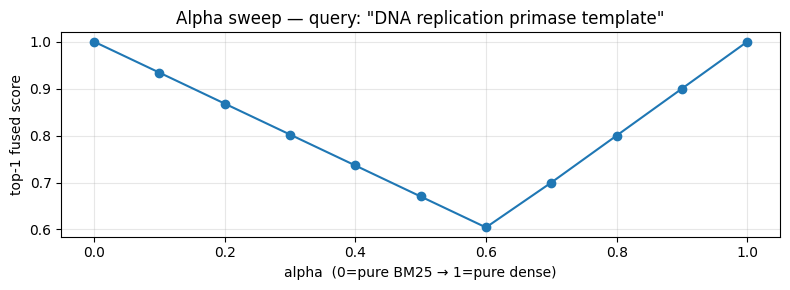

,alpha,top_score,top_chunk
0,0.0,1.0000,chs.\nDNA replication is semi-conservative: ea...
1,0.1,0.9341,chs.\nDNA replication is semi-conservative: ea...
2,0.2,0.8681,chs.\nDNA replication is semi-conservative: ea...
3,0.3,0.8022,chs.\nDNA replication is semi-conservative: ea...
4,0.4,0.7363,chs.\nDNA replication is semi-conservative: ea...
5,0.5,0.6703,chs.\nDNA replication is semi-conservative: ea...
6,0.6,0.6044,chs.\nDNA replication is semi-conservative: ea...
7,0.7,0.7000,es carbon dioxide as a byproduct.\nPhotosynthe...
8,0.8,0.8000,es carbon dioxide as a byproduct.\nPhotosynthe...
9,0.9,0.9000,es carbon dioxide as a byproduct.\nPhotosynthe...


In [26]:
import matplotlib.pyplot as plt

query  = "DNA replication primase template"
alphas = np.linspace(0, 1, 11)
rows   = []

for a in alphas:
    h = HybridRetriever(dense, bm25, alpha=float(a))
    top = h.retrieve(query, top_k=1)[0]
    rows.append({"alpha": round(float(a), 1), "top_score": round(top.score, 4), "top_chunk": top.chunk.content[:50]})

df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(df["alpha"], df["top_score"], marker="o")
ax.set_xlabel("alpha  (0=pure BM25 → 1=pure dense)")
ax.set_ylabel("top-1 fused score")
ax.set_title(f'Alpha sweep — query: "{query}"')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df

---

## 5. Metrics

### 5a. Per-query functions

In [27]:
from rag_common import metrics

retrieved = ["a", "b", "c", "d", "e"]
relevant  = {"b", "d"}

print(f"retrieved : {retrieved}")
print(f"relevant  : {relevant}")
print()
print(f"recall@5    = {metrics.recall_at_k(retrieved, relevant, 5):.3f}   (found {len(set(retrieved[:5]) & relevant)}/{len(relevant)} relevant)")
print(f"precision@5 = {metrics.precision_at_k(retrieved, relevant, 5):.3f}   ({len(set(retrieved[:5]) & relevant)}/5 top results are relevant)")
print(f"recip. rank = {metrics.reciprocal_rank(retrieved, relevant):.3f}   (first hit at rank 2 → 1/2)")
print(f"avg. prec   = {metrics.average_precision(retrieved, relevant):.3f}")
print(f"ndcg@5      = {metrics.ndcg_at_k(retrieved, relevant, 5):.3f}")

retrieved : ['a', 'b', 'c', 'd', 'e']
relevant  : {'d', 'b'}

recall@5    = 1.000   (found 2/2 relevant)
precision@5 = 0.400   (2/5 top results are relevant)
recip. rank = 0.500   (first hit at rank 2 → 1/2)
avg. prec   = 0.500
ndcg@5      = 0.651


### 5b. End-to-end evaluation on the corpus

Each chunk's own content is used as the query — the correct answer is always that chunk itself.
This tests whether the retriever can do self-retrieval (a basic sanity check).

In [28]:
def run_eval(retriever, chunks, top_k=5) -> dict:
    query_results = []
    for chunk in chunks:
        retrieved = [r.chunk.id_str() for r in retriever.retrieve(chunk.content, top_k=top_k)]
        relevant  = {chunk.id_str()}
        query_results.append((retrieved, relevant))
    return metrics.evaluate(query_results, k=top_k)


rows = []
for name, retriever in [("BM25", bm25), ("Dense", dense), ("Hybrid(α=0.6)", hybrid)]:
    scores = run_eval(retriever, chunks)
    rows.append({"retriever": name, **scores})

pd.DataFrame(rows).set_index("retriever").round(3)

,recall@5,precision@5,mrr,map,ndcg@5
retriever,,,,,
BM25,1.0,0.2,1.0,1.0,1.0
Dense,1.0,0.2,1.0,1.0,1.0
Hybrid(α=0.6),1.0,0.2,1.0,1.0,1.0


### 5c. Visualise: Recall@5 vs MRR across retrievers

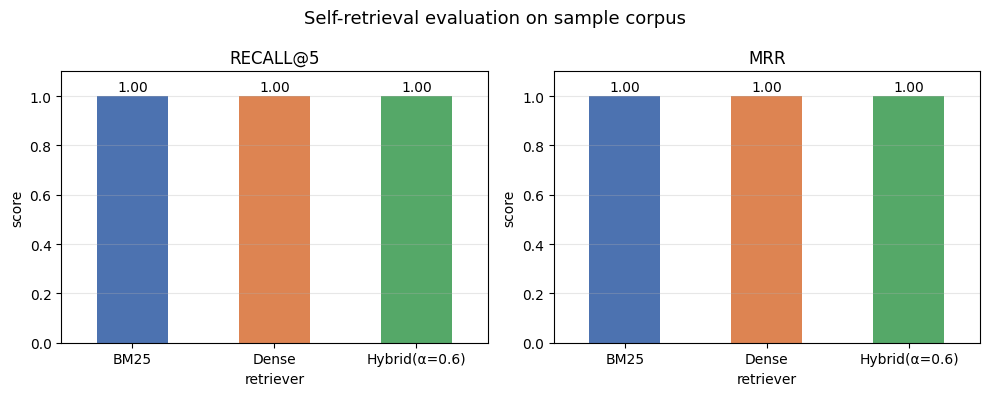

In [29]:
import matplotlib.pyplot as plt

df_scores = pd.DataFrame(rows).set_index("retriever")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric in zip(axes, ["recall@5", "mrr"]):
    df_scores[metric].plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
    ax.set_title(metric.upper())
    ax.set_ylabel("score")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", alpha=0.3)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.2f}", ha="center", fontsize=10)

plt.suptitle("Self-retrieval evaluation on sample corpus", fontsize=13)
plt.tight_layout()
plt.show()